<a href="https://colab.research.google.com/github/john-beuter/5600-ML-Final-Project/blob/main/5600_ML_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install dask-ml

In [2]:
import numpy as np
import pandas as pd
import dask.dataframe as dd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.ensemble import RandomForestClassifier

# from dask_ml.decomposition import PCA


In [3]:
#Get dataset with dask
splits = {'train': 'Baseline/*/*_train.parquet', 'test': 'Baseline/*/*_test.parquet'}
# train_df = dd.read_parquet("hf://datasets/IQSeC-Lab/LAMDA/" + splits["train"])
# test_df = dd.read_parquet("hf://datasets/IQSeC-Lab/LAMDA/" + splits["test"])

# using just the 2025 data
X_train = dd.read_parquet("hf://datasets/IQSeC-Lab/LAMDA/Baseline/2025/2025_train.parquet")
X_test = dd.read_parquet("hf://datasets/IQSeC-Lab/LAMDA/Baseline/2025/2025_test.parquet")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [4]:
# Ensure all data is numeric, drop NaN if necessary
X_train = X_train.select_dtypes(include=['int64', 'float64', 'int8'])

# Scale the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(X_train)


[4.61264949e-02 1.73629835e-02 1.70811561e-02 ... 1.22809268e-36
 5.26048379e-37 9.36875976e-38]


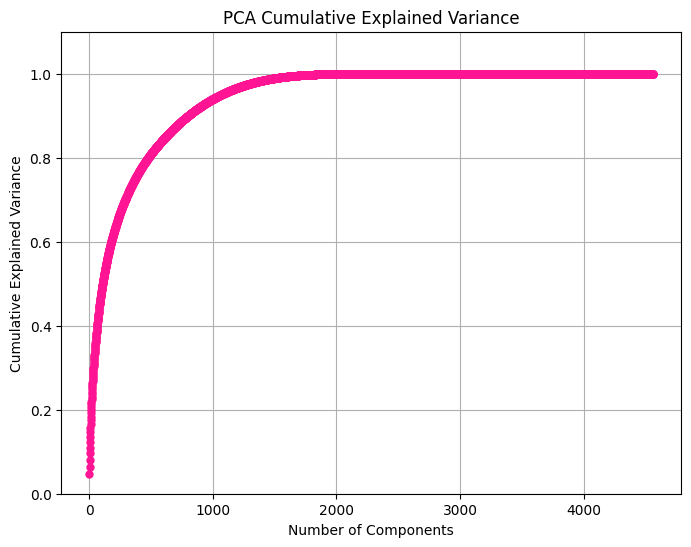

In [5]:
### PCA and Feature Extraction
pca = PCA()
pca.fit_transform(scaled_data)
print(pca.explained_variance_ratio_)
cumulative_explained_variance = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', linestyle='-', color='deeppink', markersize=5)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Cumulative Explained Variance')
plt.grid(True)
plt.ylim(0.0, 1.1)

plt.show()

In [6]:
pca_data = PCA(n_components=500).fit_transform(scaled_data)

In [7]:
### RF
rf_param_grid = {
    'n_estimators':    [100, 200],
    'max_depth':       [10, 20, None],
    'min_samples_split': [2, 5]
}

RANDOM_STATE = 42

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_base = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    rf_param_grid, scoring='f1', cv=cv, n_jobs=-1, verbose=1
)

#grid_base.fit(X_train, y_train)

In [8]:
### SVM
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, f1_score
from sklearn.calibration import CalibratedClassifierCV

LABEL_COL = 'label'

y_train_raw = X_train[LABEL_COL].compute().values
y_test_raw  = X_test[LABEL_COL].compute().values


X_test_numeric = X_test.select_dtypes(include=['int64', 'float64', 'int8'])
X_test_scaled  = scaler.transform(X_test_numeric)
X_test_pca     = PCA(n_components=500).fit(scaled_data).transform(X_test_scaled)

svm_param_grid = {
    'svc__C': [0.01, 0.1, 1.0, 10.0],
    'svc__max_iter': [2000]
}

svm_pipeline = Pipeline([
    ('svc', LinearSVC(random_state=RANDOM_STATE, dual=False))
])

grid_svm = GridSearchCV(
    svm_pipeline,
    svm_param_grid,
    scoring='f1_weighted',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_svm.fit(pca_data, y_train_raw)

print("Best SVM params:", grid_svm.best_params_)
print("Best CV F1 (weighted):", grid_svm.best_score_)

y_pred_svm = grid_svm.predict(X_test_pca)

print("\nSVM Classification Report:")
print(classification_report(y_test_raw, y_pred_svm))
print("SVM Test F1 (weighted):", f1_score(y_test_raw, y_pred_svm, average='weighted'))

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best SVM params: {'svc__C': 0.01, 'svc__max_iter': 2000}
Best CV F1 (weighted): 0.9997156615954884

SVM Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8928
           1       0.83      1.00      0.91         5

    accuracy                           1.00      8933
   macro avg       0.92      1.00      0.95      8933
weighted avg       1.00      1.00      1.00      8933

SVM Test F1 (weighted): 0.9998931407748902
